# Clustering de propiedades Airbnb Buenos Aires
## P5 - ML No Supervisado

### Objetivo
Segmentar las 27.348 propiedades en grupos de negocio usando
K-means y DBSCAN. Usar PCA para visualizar los clusters en 2D.

### Dataset
- Fuente: BigQuery -> portfolio-ds-494722.airbnb_analytics.airbnb_gold
- 27.348 propiedades x 13 columnas

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from google.cloud import bigquery

import warnings
warnings.filterwarnings('ignore')

In [2]:
# Cargar datos desde BigQuery
cliente = bigquery.Client(project="portfolio-ds-494722")

query = '''
    SELECT
        id,
        neighbourhood_cleansed,
        room_type,
        accommodates,
        bathrooms,
        beds,
        review_scores_rating,
        reviews_per_month,
        tiene_resenas,
        antiguedad_total
    FROM portfolio-ds-494722.airbnb_analytics.airbnb_gold
    WHERE review_scores_rating IS NOT NULL
      AND reviews_per_month IS NOT NULL
      AND antiguedad_total IS NOT NULL
'''

df = cliente.query(query).to_dataframe()
print(f"Shape: {df.shape}")
df.head()

Shape: (24045, 10)


,id,neighbourhood_cleansed,room_type,accommodates,bathrooms,beds,review_scores_rating,reviews_per_month,tiene_resenas,antiguedad_total
0,14563636,Palermo,Entire home/apt,9,3.0,5.0,4.92,0.84,1,3403.0
1,43590926,Constitucion,Entire home/apt,15,5.5,11.0,4.92,1.85,1,1281.0
2,750667399381871003,Palermo,Entire home/apt,10,3.5,11.0,4.95,1.97,1,1171.0
3,16415492,Palermo,Entire home/apt,9,3.0,5.0,4.94,0.83,1,3220.0
4,879443163026006927,Palermo,Entire home/apt,10,4.0,7.0,5.00,2.97,1,917.0


## 2. Preprocesamiento

In [3]:
# Seleccionar features numéricas para clustering
features = [
    "accommodates",
    "bathrooms", 
    "beds",
    "review_scores_rating",
    "reviews_per_month",
    "antiguedad_total"
]

X = df[features].copy()

# Escalar
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"Features seleccionadas: {features}")
print(f"Shape antes de escalar: {X.shape}")
print(f"Shape después de escalar: {X_scaled.shape}")
print(f"\nMedia después de escalar (debe ser ~0):")
print(X_scaled.mean(axis=0).round(4))

Features seleccionadas: ['accommodates', 'bathrooms', 'beds', 'review_scores_rating', 'reviews_per_month', 'antiguedad_total']
Shape antes de escalar: (24045, 6)
Shape después de escalar: (24045, 6)

Media después de escalar (debe ser ~0):
[ 0. -0. -0.  0. -0. -0.]


## 3. PCA - Reducción de dimensionalidad

In [4]:
# Reducir a 2 componenentes para visualización
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print(f"Varianza explicada por cada componente:")
print(f"  PC1: {pca.explained_variance_ratio_[0]:.2%}")
print(f"  PC2: {pca.explained_variance_ratio_[1]:.2%}")
print(f"  Total: {sum(pca.explained_variance_ratio_):.2%}")

Varianza explicada por cada componente:
  PC1: 35.56%
  PC2: 20.91%
  Total: 56.46%


## 4. K-Means — Selección del K óptimo

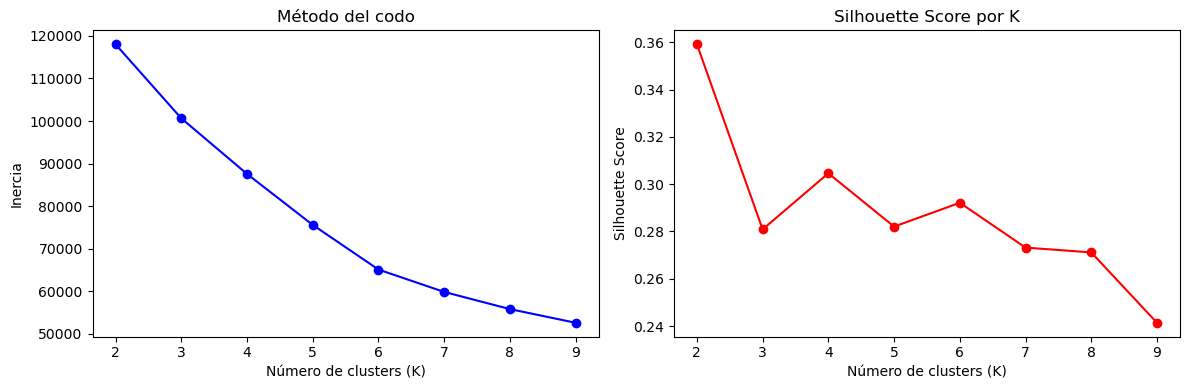

In [12]:
%matplotlib inline

# Método del codo
inercias = []
silhouettes = []
rango_k = range(2,10)

for k in rango_k:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inercias.append(kmeans.inertia_)
    silhouettes.append(silhouette_score(X_scaled, kmeans.labels_))

# Graficar
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12,4))

ax1.plot(rango_k, inercias, 'bo-')
ax1.set_xlabel('Número de clusters (K)')
ax1.set_ylabel('Inercia')
ax1.set_title('Método del codo')

ax2.plot(rango_k, silhouettes, 'ro-')
ax2.set_xlabel('Número de clusters (K)')
ax2.set_ylabel('Silhouette Score')
ax2.set_title('Silhouette Score por K')

plt.tight_layout()
plt.show()

